In [35]:
import numpy as np
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

# Menghapus kolom yang tidak diperlukan
df = df.drop(df.iloc[:, 2:], axis=1)

# Rename kolom
df.columns = ['Labels', 'Message']

df.head()

print(df['Labels'].value_counts())

X = df['Message']
y = df['Labels']

Labels
ham     4825
spam     747
Name: count, dtype: int64


In [36]:
#Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50
)

In [37]:
#CountVectorizer + Stopwords
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(stop_words='english')

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

mnb_bow = MultinomialNB()

mnb_bow.fit(X_train_bow, y_train)

y_pred_bow = mnb_bow.predict(X_test_bow)

acc_bow = accuracy_score(y_test, y_pred_bow)

print("CountVectorizer Accuracy:", acc_bow)

CountVectorizer Accuracy: 0.9829596412556054


In [39]:
#Evaluasi CountVectorizer
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bow))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       954
        spam       0.98      0.90      0.94       161

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [41]:
#Feature TF-IDF by + stop_words
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [42]:
mnb_tfidf = MultinomialNB()

mnb_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("TF-IDF Accuracy:", acc_tfidf)

TF-IDF Accuracy: 0.9605381165919282


In [43]:
#Evaluasi TF-IDF
print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       954
        spam       1.00      0.73      0.84       161

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [45]:
#Comparison of CountVectorizer and TF-IDF
comparison = pd.DataFrame({
    'Feature': ['CountVectorizer', 'TF-IDF'],
    'Accuracy': [acc_bow, acc_tfidf]
})

print(comparison)

           Feature  Accuracy
0  CountVectorizer  0.982960
1           TF-IDF  0.960538


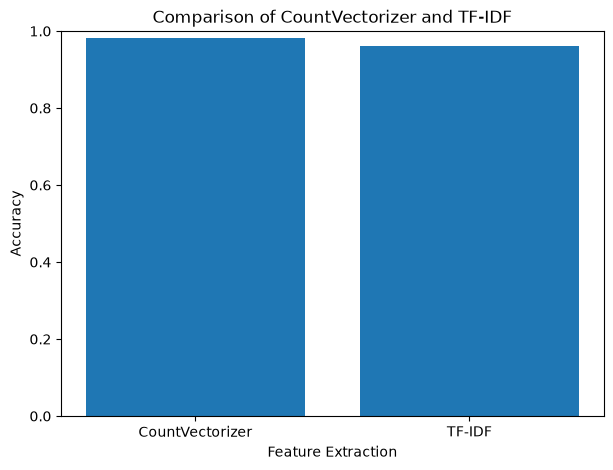

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    comparison['Feature'],
    comparison['Accuracy']
)

plt.xlabel('Feature Extraction')
plt.ylabel('Accuracy')
plt.title('Comparison of CountVectorizer and TF-IDF')

plt.ylim(0, 1)
plt.show()

#### A. Multinomial Naive Bayes dengan CountVectorizer + Stop Words
Pada percobaan pertama, digunakan metode CountVectorizer dengan mengaktifkan stop_words='english' untuk menghilangkan kata-kata umum yang kurang informatif. Hasil representasi teks kemudian digunakan sebagai input untuk model Multinomial Naive Bayes. Model dievaluasi menggunakan accuracy, precision, recall, dan F1-score.

- Training accuracy: 0.9946152120260264
- Testing accuracy: 0.9829596412556054

#### B. Multinomial Naive Bayes dengan TF-IDF + Stop Words
Pada percobaan kedua, CountVectorizer digantikan dengan TF-IDF Vectorizer dengan mengaktifkan stop_words='english'. TF-IDF memberikan bobot pada setiap kata berdasarkan tingkat kepentingannya dalam dokumen. Hasil transformasi kemudian digunakan untuk melatih model Multinomial Naive Bayes.

- Training accuracy: 0.9842943684092439
- Testing accuracy: 0.9605381165919282

| Feature / Experiment | Test Accuracy |
|---|---:|
| CountVectorizer + Stop Words | **98.30%** |
| TF-IDF + Stop Words | **96.05%** |
